In [141]:
import pandas as pd

In [142]:
df_old = pd.read_csv('UFC.csv')

In [143]:
# Convert your date column to datetime if you haven't already
df_old['date'] = pd.to_datetime(df_old['date'])

# Filter for the 'Modern Era' (e.g., 2010 onwards)
df = df_old[df_old['date'].dt.year >= 2010].copy()

# Check how many rows are left
print(f"Original fights: {len(df_old)}")
print(f"Modern fights: {len(df)}")

Original fights: 8662
Modern fights: 7397


In [144]:
def knock_down_difference(df):
    df['kd_dif'] = df['r_kd'] - df['r_kd']
    return df

In [145]:
def sig_str_acc_difference(df):
    df['sig_str_acc_dif'] = df['r_sig_str_acc'] - df['b_sig_str_acc']
    return df


In [146]:
def sig_str_landed_difference(df):
    df['sig_str_landed_dif'] = df['r_sig_str_landed'] - df['b_sig_str_landed']
    return df

In [147]:
def total_str(df):

    df['total_str_landed_dif'] = df['r_total_str_landed'] - df['b_total_str_landed']
    df['total_str_atmpted_dif'] = df['b_total_str_atmpted'] - df['b_total_str_atmpted']
    df['total_str_acc_dif'] = df['r_total_str_acc'] - df['b_total_str_acc']

    df['total_str_landed_pct_dif'] = (df['r_total_str_landed'] - df['b_total_str_landed']) / (df['b_total_str_landed'] + 1)
    
    return df

In [157]:
def grappling_features(df):
    # 1. Takedown Differentials
    # Landed tells us offensive success; Accuracy tells us efficiency.
    df['td_landed_dif'] = df['r_td_landed'] - df['b_td_landed']
    df['td_atmp_dif'] = df['r_td_atmpted'] - df['b_td_atmpted']
    df['td_acc_dif'] = df['r_td_acc'] - df['b_td_acc']

    # 2. Submission Threat Differential
    # This captures the 'finishing' ability on the ground.
    df['sub_att_dif'] = df['r_sub_att'] - df['b_sub_att']
    
    # 3. Control Time Differential
    # Control time is often a 'king' stat for judges. 
    # Ensure this is in a numeric format (like total seconds) before subtracting.
    df['ctrl_time_dif'] = df['r_ctrl'] - df['b_ctrl']

    return df

In [149]:
def strike_distribution(df):
    """
    Calculates differentials for specific strike targets and positions.
    Covers: Head, Body, Leg, Distance, Clinch, and Ground.
    """
    
    # 1. Target Differentials (Head, Body, Leg)
    df['head_landed_dif'] = df['r_head_landed'] - df['b_head_landed']
    df['head_acc_dif'] = df['r_head_acc'] - df['b_head_acc']
    
    df['body_landed_dif'] = df['r_body_landed'] - df['b_body_landed']
    df['body_acc_dif'] = df['r_body_acc'] - df['b_body_acc']
    
    df['leg_landed_dif'] = df['r_leg_landed'] - df['b_leg_landed']
    df['leg_acc_dif'] = df['r_leg_acc'] - df['b_leg_acc']
    
    # 2. Position Differentials (Distance, Clinch, Ground)
    # Distance: Strikes landed while both fighters are standing/neutral
    df['dist_landed_dif'] = df['r_dist_landed'] - df['b_dist_landed']
    df['dist_acc_dif'] = df['r_dist_acc'] - df['b_dist_acc']
    
    # Clinch: Strikes landed during grappling exchanges against the cage/standing
    df['clinch_landed_dif'] = df['r_clinch_landed'] - df['b_clinch_landed']
    df['clinch_acc_dif'] = df['r_clinch_acc'] - df['b_clinch_acc']
    
    # Ground: Strikes landed while on the mat (Ground and Pound)
    df['ground_landed_dif'] = df['r_ground_landed'] - df['b_ground_landed']
    # Note: Ensure r_ground_ in your CSV refers to landed or accuracy as needed
    
    return df

In [150]:
def physical_features(df):
    # Reach and Height advantages
    df['reach_dif'] = df['r_reach'] - df['b_reach']
    df['height_dif'] = df['r_height'] - df['b_height']
    
    # Convert date columns so DOB-based age can be calculated reliably
    fight_date = pd.to_datetime(df['date'], errors='coerce')
    red_dob = pd.to_datetime(df['r_dob'], errors='coerce')
    blue_dob = pd.to_datetime(df['b_dob'], errors='coerce')
    
    # Age calculation from DOB
    df['r_age'] = (fight_date - red_dob).dt.days / 365.25
    df['b_age'] = (fight_date - blue_dob).dt.days / 365.25
    df['age_dif'] = df['r_age'] - df['b_age']
    
    return df

In [151]:
def performance_metrics(df):
    # The 'Efficiency' Gap
    # A positive number here means Red lands more and takes less than Blue
    df['net_striking_gap'] = (df['r_splm'] - df['r_sapm']) - (df['b_splm'] - df['b_sapm'])
    
    # Defense Differentials
    df['str_def_dif'] = df['r_str_def'] - df['b_str_def']
    df['td_def_dif'] = df['r_td_def'] - df['b_td_def']
    
    # Experience / Record
    df['total_fights_r'] = df['r_wins'] + df['r_losses'] + df['r_draws']
    df['experience_dif'] = df['total_fights_r'] - (df['b_wins'] + df['b_losses'] + df['b_draws'])
    
    return df 

In [152]:
def missing_stance(df):
    df['r_stance'] = df['r_stance'].fillna('orthodox')
    df['b_stance'] = df['b_stance'].fillna('orthodox')
    return df

In [153]:
def stance_features(df):
    """
    Converts categorical stance into numerical features.
    Focuses on the 'Southpaw' vs 'Orthodox' dynamic.
    """
    
    # 1. Standardize text (remove whitespace and lowercase)
    df['r_stance'] = df['r_stance'].str.strip().str.lower()
    df['b_stance'] = df['b_stance'].str.strip().str.lower()
    
    # 2. Binary Southpaw check
    # Many models find that simply being a Southpaw is a distinct feature.
    df['r_is_southpaw'] = (df['r_stance'] == 'southpaw').astype(int)
    df['b_is_southpaw'] = (df['b_stance'] == 'southpaw').astype(int)
    
    # 3. Matchup Type (The "Open Guard" Feature)
    # 1 if it's Orthodox vs Southpaw (different stances)
    # 0 if it's Orthodox vs Orthodox or Southpaw vs Southpaw (same stance)
    df['is_opposing_stance'] = (df['r_stance'] != df['b_stance']).astype(int)
    
    # 4. Handle Switch Stance
    # Switch hitters can be a nightmare for the model; we flag them specifically.
    df['r_is_switch'] = (df['r_stance'] == 'switch').astype(int)
    df['b_is_switch'] = (df['b_stance'] == 'switch').astype(int)
    
    return df

In [154]:
def create_target_label(df):
    """
    Creates a binary target column: 
    1 if Red (R) won, 0 if Blue (B) won.
    """
    
    # 1. Logic check: If winner_id matches the Red fighter's ID, Red won (1)
    # 2. If it matches the Blue fighter's ID, Blue won (0)
    # 3. We use .astype(int) to make it XGBoost-ready
    
    df['target'] = (df['winner_id'] == df['r_id']).astype(int)
    
    return df

In [155]:
# Build the feature columns before selecting them into X

df = knock_down_difference(df)
df = sig_str_acc_difference(df)
df = sig_str_landed_difference(df)
df = total_str(df)
df = grappling_features(df)
df = strike_distribution(df)
df = physical_features(df)
df = performance_metrics(df)
df = missing_stance(df)
df = stance_features(df)
df = create_target_label(df)

In [ ]:
features = [
    'kd_dif',
    'sig_str_acc_dif',
    'sig_str_landed_dif',
    'total_str_landed_dif',
    'total_str_atmpted_dif',
    'total_str_acc_dif',
    'total_str_landed_pct_dif',
    'td_landed_dif',
    'td_atmp_dif',
    'td_acc_dif',
    'sub_att_dif',
    'ctrl_time_dif',
    'head_landed_dif',
    'head_acc_dif',
    'body_landed_dif',
    'body_acc_dif',
    'leg_landed_dif',
    'leg_acc_dif',
    'dist_landed_dif',
    'dist_acc_dif',
    'clinch_landed_dif',
    'clinch_acc_dif',
    'ground_landed_dif',
    'reach_dif',
    'height_dif',
    'r_age',
    'b_age',
    'age_dif',
    'net_striking_gap',
    'str_def_dif',
    'td_def_dif',
    'total_fights_r',
    'experience_dif',
    'r_is_southpaw',
    'b_is_southpaw',
    'is_opposing_stance',
    'r_is_switch',
    'b_is_switch',
    
]

X = df[features]
y = df['target'] # Or whatever your target column is named

# 3. Handle any missing data (common in UFC sets)
X = X.fillna(0)

In [160]:
# Identify any non-numeric columns in your feature list
non_numeric = df[features].select_dtypes(exclude=['number']).columns

if len(non_numeric) > 0:
    print(f"⚠️ Warning! These columns need to be converted to numbers: {list(non_numeric)}")
else:
    print("✅ All features are numeric. Ready for XGBoost!")

✅ All features are numeric. Ready for XGBoost!


In [161]:
# Split the dataset by fight year
train_df = df[(df['date'].dt.year >= 2010) & (df['date'].dt.year <= 2024)].copy()
test_df = df[(df['date'].dt.year >= 2025) & (df['date'].dt.year <= 2026)].copy()

X_train = train_df[features].fillna(0)
y_train = train_df['target']

X_test = test_df[features].fillna(0)
y_test = test_df['target']

print(f"Training fights: {len(train_df)}")
print(f"Testing fights: {len(test_df)}")

Training fights: 6709
Testing fights: 688


In [162]:
# Check this:
print(len(features)) 
print(X_train.shape[1]) # These must be identical

38
38


In [163]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the XGBoost Classifier
# use_label_encoder=False and eval_metric='logloss' are standard for binary tasks
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train the model using our 2010-2024 data
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [164]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy on 2025-2026 fights: {accuracy:.2%}")

Baseline Accuracy on 2025-2026 fights: 87.94%


In [165]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       312
           1       0.88      0.90      0.89       376

    accuracy                           0.88       688
   macro avg       0.88      0.88      0.88       688
weighted avg       0.88      0.88      0.88       688

Confusion Matrix:
[[268  44]
 [ 39 337]]


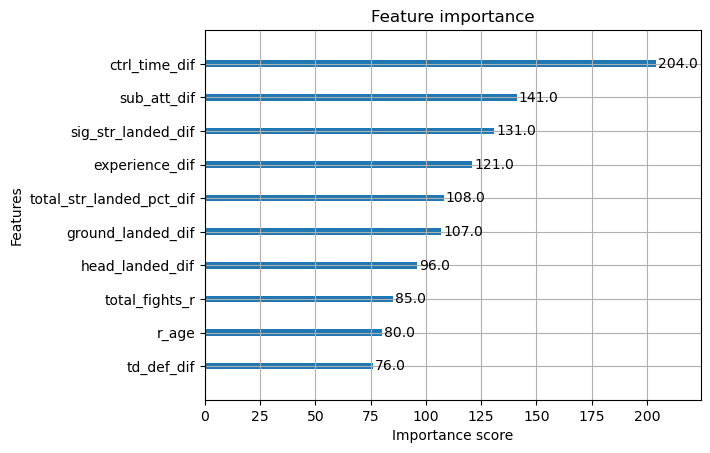

In [166]:
# View the top 10 features
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=10)
plt.show()